# Federated Learning: Satellite Constellation Simulation

This notebook simulates independent satellite clients for UNSW-NB15. Only normal rows from the training CSV are divided among clients. Each client trains a local autoencoder, and Federated Averaging (FedAvg) combines the local weights into a global model.

The test CSV is never used for fitting or threshold calibration. A separate normal calibration split is held out from the client data and is used only to calibrate the global anomaly threshold after each communication round. SHAP, LIME, threat scoring, and dashboard work are outside this notebook.

In [1]:
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
N_CLIENTS = 5
N_ROUNDS = 5
LOCAL_EPOCHS = 2
BATCH_SIZE = 256
np.random.seed(SEED)
tf.random.set_seed(SEED)
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
# Locate the repository whether the notebook is run from notebooks/ or its parent.
project_root = Path.cwd().resolve()
for candidate in (project_root, project_root.parent):
    if (candidate / 'dataset' / 'UNSW-NB15').exists():
        project_root = candidate
        break
if not (project_root / 'dataset' / 'UNSW-NB15').exists():
    raise FileNotFoundError('Could not find dataset/UNSW-NB15 from the notebook or its parent folder.')

data_dir = project_root / 'dataset' / 'UNSW-NB15'
model_dir = project_root / 'models' / 'trained_models'
metrics_dir = project_root / 'results' / 'metrics'
plots_dir = project_root / 'results' / 'plots'
for directory in (model_dir, metrics_dir, plots_dir):
    directory.mkdir(parents=True, exist_ok=True)

train_df = pd.read_csv(data_dir / 'UNSW_NB15_training-set.csv')
test_df = pd.read_csv(data_dir / 'UNSW_NB15_testing-set.csv')
pipeline_path = project_root / 'models' / 'preprocessing_pipeline.pkl'
if not pipeline_path.exists():
    raise FileNotFoundError('Run 02_Data_Preprocessing.ipynb first to create preprocessing_pipeline.pkl.')
with pipeline_path.open('rb') as file:
    preprocessor = pickle.load(file)

feature_cols = [column for column in train_df.columns if column not in ('label', 'attack_cat')]
X_train = np.asarray(preprocessor.transform(train_df[feature_cols]), dtype=np.float32)
X_test = np.asarray(preprocessor.transform(test_df[feature_cols]), dtype=np.float32)
y_train = train_df['label'].astype(int).to_numpy()
y_test = test_df['label'].astype(int).to_numpy()
print(f'Train: {X_train.shape}, test: {X_test.shape}, processed features: {X_train.shape[1]}')

Train: (175341, 195), test: (82332, 195), processed features: 195


In [3]:
# Split normal training rows once. Clients receive only the client pool.
normal_indices = np.flatnonzero(y_train == 0)
client_indices, calibration_indices = train_test_split(
    normal_indices, test_size=0.2, random_state=SEED, shuffle=True
)
rng = np.random.default_rng(SEED)
shuffled_client_indices = rng.permutation(client_indices)
client_splits = np.array_split(shuffled_client_indices, N_CLIENTS)

# These checks make the intended isolation explicit.
assert set(calibration_indices).isdisjoint(set(client_indices))
assert sum(len(split) for split in client_splits) == len(client_indices)
assert len(set(np.concatenate(client_splits))) == len(client_indices)
assert len(client_indices) + len(calibration_indices) == len(normal_indices)
print(f'Normal training rows: {len(normal_indices)}')
print(f'Client pool: {len(client_indices)}, calibration-only normals: {len(calibration_indices)}')
print('Client sizes:', [len(split) for split in client_splits])
print(f'Test rows used only for evaluation: {len(X_test)}')

Normal training rows: 56000
Client pool: 44800, calibration-only normals: 11200
Client sizes: [8960, 8960, 8960, 8960, 8960]
Test rows used only for evaluation: 82332


In [4]:
def build_autoencoder(input_dim):
    latent_dim = min(32, max(4, input_dim // 4))
    model = keras.Sequential(
        [
            keras.Input(shape=(input_dim,), name='features'),
            layers.Dense(64, activation='relu', name='encoder'),
            layers.Dense(latent_dim, activation='relu', name='latent'),
            layers.Dense(64, activation='relu', name='decoder'),
            layers.Dense(input_dim, activation='linear', name='reconstruction'),
        ],
        name='unsw_nb15_federated_autoencoder',
    )
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss='mse')
    return model

def reconstruction_errors(model, features):
    reconstructed = model.predict(features, batch_size=1024, verbose=0)
    return np.mean(np.square(features - reconstructed), axis=1)

def fed_avg(weight_sets, sample_counts):
    total_samples = float(sum(sample_counts))
    return [
        sum(weights[layer] * count for weights, count in zip(weight_sets, sample_counts)) / total_samples
        for layer in range(len(weight_sets[0]))
    ]

## FedAvg communication rounds

At each round, every client starts from the current global weights, trains locally on its own normal traffic, and returns weights. The server computes a sample-count-weighted average. The calibration split determines the round threshold; the untouched test set determines anomaly metrics.

In [5]:
global_model = build_autoencoder(X_train.shape[1])
round_records = []

for round_number in range(1, N_ROUNDS + 1):
    global_weights = global_model.get_weights()
    local_weight_sets = []
    sample_counts = []

    for client_number, indices in enumerate(client_splits, start=1):
        local_model = build_autoencoder(X_train.shape[1])
        local_model.set_weights(global_weights)
        local_features = X_train[indices]
        local_model.fit(
            local_features, local_features, epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE,
            shuffle=True, verbose=0,
        )
        local_weight_sets.append(local_model.get_weights())
        sample_counts.append(len(indices))

    global_model.set_weights(fed_avg(local_weight_sets, sample_counts))
    calibration_errors = reconstruction_errors(global_model, X_train[calibration_indices])
    test_errors = reconstruction_errors(global_model, X_test)
    threshold = float(np.percentile(calibration_errors, 95))
    test_predictions = (test_errors > threshold).astype(int)
    record = {
        'round': round_number,
        'global_calibration_loss': float(np.mean(calibration_errors)),
        'global_test_reconstruction_loss': float(np.mean(test_errors)),
        'threshold': threshold,
        'accuracy': accuracy_score(y_test, test_predictions),
        'precision': precision_score(y_test, test_predictions, zero_division=0),
        'recall': recall_score(y_test, test_predictions, zero_division=0),
        'f1_score': f1_score(y_test, test_predictions, zero_division=0),
        'roc_auc': roc_auc_score(y_test, test_errors),
    }
    round_records.append(record)
    print(
        f"Round {round_number}/{N_ROUNDS}: calibration loss={record['global_calibration_loss']:.6f}, "
        f"test F1={record['f1_score']:.4f}, ROC-AUC={record['roc_auc']:.4f}"
    )

Round 1/5: calibration loss=0.077881, test F1=0.2552, ROC-AUC=0.6848


Round 2/5: calibration loss=0.035281, test F1=0.3038, ROC-AUC=0.7577


Round 3/5: calibration loss=0.022384, test F1=0.2862, ROC-AUC=0.7898


Round 4/5: calibration loss=0.014641, test F1=0.3802, ROC-AUC=0.8157


Round 5/5: calibration loss=0.010330, test F1=0.4821, ROC-AUC=0.8365


In [6]:
federated_metrics = pd.DataFrame(round_records)
round_metrics_path = metrics_dir / '05_federated_learning_metrics.csv'
federated_metrics.to_csv(round_metrics_path, index=False)

# Load the Step 3 baseline metrics when available for a direct comparison.
baseline_metrics_path = metrics_dir / '03_autoencoder_metrics.csv'
if not baseline_metrics_path.exists():
    baseline_metrics_path = plots_dir / '03_autoencoder_metrics.csv'
baseline_metrics = pd.read_csv(baseline_metrics_path, index_col=0)['value'].to_dict() if baseline_metrics_path.exists() else {}
comparison = pd.DataFrame(
    [
        {'model': 'Step 3 baseline', **baseline_metrics},
        {'model': 'Federated global (final round)', **federated_metrics.iloc[-1].to_dict()},
    ]
).set_index('model')
comparison_path = metrics_dir / '05_federated_vs_baseline_metrics.csv'
comparison.to_csv(comparison_path)
print(comparison.to_string(float_format=lambda value: f'{value:.4f}'))
print(f'Round metrics saved to {round_metrics_path}')
print(f'Comparison saved to {comparison_path}')

                                accuracy  precision  recall  f1_score  roc_auc  round  global_calibration_loss  global_test_reconstruction_loss  threshold
model                                                                                                                                                     
Step 3 baseline                   0.8163     0.9082  0.7413    0.8163   0.8825    NaN                      NaN                              NaN        NaN
Federated global (final round)    0.6007     0.8434  0.3375    0.4821   0.8365 5.0000                   0.0103                           0.0442     0.0312
Round metrics saved to C:\Users\Aliya\OneDrive\Desktop\sem 4\Autonomous_Zero_Day_Detection\Autonomous_Zero_Day_Detection\results\metrics\05_federated_learning_metrics.csv
Comparison saved to C:\Users\Aliya\OneDrive\Desktop\sem 4\Autonomous_Zero_Day_Detection\Autonomous_Zero_Day_Detection\results\metrics\05_federated_vs_baseline_metrics.csv


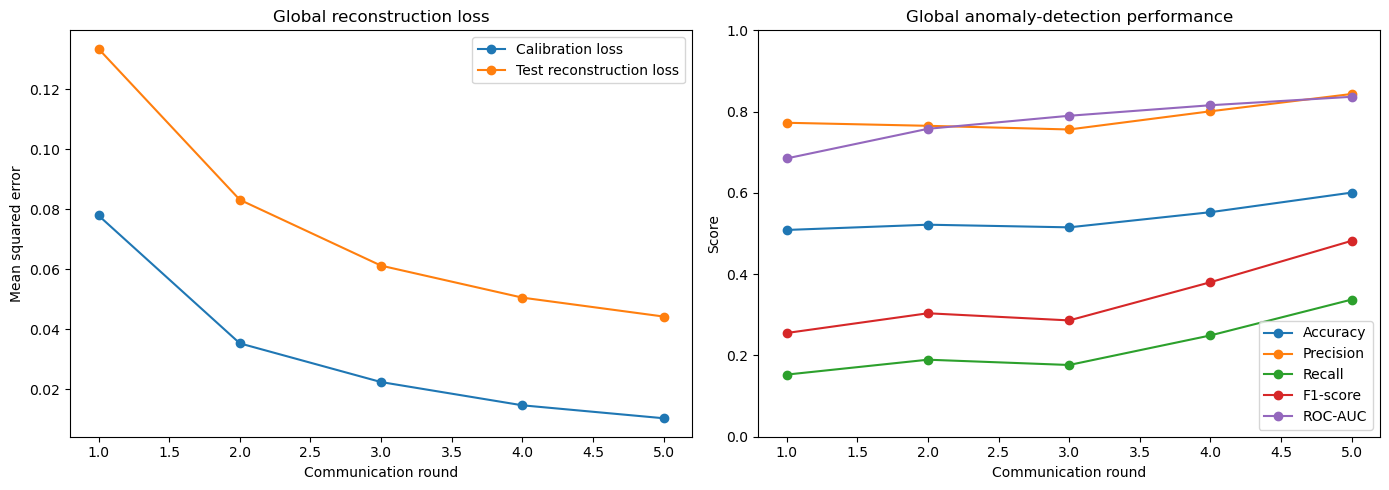

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(federated_metrics['round'], federated_metrics['global_calibration_loss'], marker='o', label='Calibration loss')
axes[0].plot(federated_metrics['round'], federated_metrics['global_test_reconstruction_loss'], marker='o', label='Test reconstruction loss')
axes[0].set(xlabel='Communication round', ylabel='Mean squared error', title='Global reconstruction loss')
axes[0].legend()
axes[1].plot(federated_metrics['round'], federated_metrics['accuracy'], marker='o', label='Accuracy')
axes[1].plot(federated_metrics['round'], federated_metrics['precision'], marker='o', label='Precision')
axes[1].plot(federated_metrics['round'], federated_metrics['recall'], marker='o', label='Recall')
axes[1].plot(federated_metrics['round'], federated_metrics['f1_score'], marker='o', label='F1-score')
axes[1].plot(federated_metrics['round'], federated_metrics['roc_auc'], marker='o', label='ROC-AUC')
axes[1].set(xlabel='Communication round', ylabel='Score', title='Global anomaly-detection performance')
axes[1].set_ylim(0, 1)
axes[1].legend()
fig.tight_layout()
fig.savefig(plots_dir / '05_federated_learning_round_metrics.png', dpi=200)
plt.show()

In [8]:
global_model_path = model_dir / 'federated_autoencoder_model.h5'
global_model.save(global_model_path)
metadata_path = model_dir / 'federated_autoencoder_metadata.pkl'
with metadata_path.open('wb') as file:
    pickle.dump(
        {
            'anomaly_threshold': float(federated_metrics.iloc[-1]['threshold']),
            'threshold_percentile': 95,
            'input_dim': X_train.shape[1],
            'n_clients': N_CLIENTS,
            'n_rounds': N_ROUNDS,
            'local_epochs': LOCAL_EPOCHS,
            'feature_columns': feature_cols,
            'calibration_rows': len(calibration_indices),
        },
        file,
    )
print(f'Global model saved to {global_model_path}')
print(f'Metadata saved to {metadata_path}')
print(f'Plot saved to {plots_dir / "05_federated_learning_round_metrics.png"}')

Global model saved to C:\Users\Aliya\OneDrive\Desktop\sem 4\Autonomous_Zero_Day_Detection\Autonomous_Zero_Day_Detection\models\trained_models\federated_autoencoder_model.h5
Metadata saved to C:\Users\Aliya\OneDrive\Desktop\sem 4\Autonomous_Zero_Day_Detection\Autonomous_Zero_Day_Detection\models\trained_models\federated_autoencoder_metadata.pkl
Plot saved to C:\Users\Aliya\OneDrive\Desktop\sem 4\Autonomous_Zero_Day_Detection\Autonomous_Zero_Day_Detection\results\plots\05_federated_learning_round_metrics.png
